In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/arinduwanniarachchi/market-data-analysis-and-machine-learning/cleaned_market_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Complete")

Setup Complete


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/arinduwanniarachchi/market-data-analysis-and-machine-learning/cleaned_market_data.csv


In [5]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/arinduwanniarachchi/market-data-analysis-and-machine-learning/cleaned_market_data.csv'
)

df.head()


,Index,Date,Open,High,Low,Close,Adj Close,Volume,Volume_Available,Target
0,000001.SS,1997-07-02,1255.909058,1261.571045,1147.331055,1199.061035,1199.061035,0.0,0,0
1,000001.SS,1997-07-03,1194.676025,1194.676025,1149.939941,1150.623047,1150.623047,0.0,0,1
2,000001.SS,1997-07-04,1138.921021,1163.249023,1124.776001,1159.342041,1159.342041,0.0,0,0
3,000001.SS,1997-07-07,1161.707031,1163.447021,1085.572021,1096.818970,1096.818970,0.0,0,1
4,000001.SS,1997-07-08,1092.798950,1115.432983,1066.043945,1109.666016,1109.666016,0.0,0,1


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(110223, 10)

Column Names:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Volume_Available', 'Target']

Data Types:
Index                object
Date                 object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
Volume_Available      int64
Target                int64
dtype: object


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Index               0
Date                0
Open                0
High                0
Low                 0
Close               0
Adj Close           0
Volume              0
Volume_Available    0
Target              0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Volume_Available,Target
count,110223.000000,110223.000000,110223.000000,110223.000000,110223.000000,1.102230e+05,110223.000000,110223.000000
mean,7658.181324,7704.138129,7607.662062,7657.207832,7657.063526,1.274129e+09,0.618274,0.530815
std,9009.715510,9064.809928,8952.727790,9009.721995,9009.796704,4.316222e+09,0.485812,0.499052
min,54.869999,54.869999,54.869999,54.869999,54.869999,0.000000e+00,0.000000,0.000000
25%,1855.890015,1865.340027,1844.350036,1855.945007,1855.364990,0.000000e+00,0.000000,0.000000
50%,5194.879883,5227.689941,5155.330078,5195.549805,5195.609863,4.333000e+05,1.000000,1.000000
75%,10133.685060,10205.950195,10059.865235,10132.469725,10132.469725,1.734575e+08,1.000000,1.000000
max,68775.062500,69403.750000,68516.992190,68775.062500,68775.062500,9.440374e+10,1.000000,1.000000


In [10]:
print("Number of unique indexes:", df['Index'].nunique())

Number of unique indexes: 14


In [11]:
print(df['Index'].unique()[:20])

['000001.SS' '399001.SZ' 'GDAXI' 'GSPTSE' 'HSI' 'IXIC' 'J203.JO' 'KS11'
 'N100' 'N225' 'NSEI' 'NYA' 'SSMI' 'TWII']


In [12]:
print(df['Target'].value_counts())

Target
1    58508
0    51715
Name: count, dtype: int64


In [13]:
print(df['Target'].value_counts(normalize=True) * 100)

Target
1    53.08148
0    46.91852
Name: proportion, dtype: float64


## Feature Engineering

The Date column contains useful time-related information.
Instead of using the raw Date value directly, we extract
Year, Month, Day, and Day of Week as new features.

This helps represent temporal patterns in the dataset.

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek

In [25]:
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,Volume_Available,Target,Year,Month,Day,Day_of_Week
0,000001.SS,1997-07-02,1255.909058,1261.571045,1147.331055,1199.061035,1199.061035,0.0,0,0,1997,7,2,2
1,000001.SS,1997-07-03,1194.676025,1194.676025,1149.939941,1150.623047,1150.623047,0.0,0,1,1997,7,3,3
2,000001.SS,1997-07-04,1138.921021,1163.249023,1124.776001,1159.342041,1159.342041,0.0,0,0,1997,7,4,4
3,000001.SS,1997-07-07,1161.707031,1163.447021,1085.572021,1096.818970,1096.818970,0.0,0,1,1997,7,7,0
4,000001.SS,1997-07-08,1092.798950,1115.432983,1066.043945,1109.666016,1109.666016,0.0,0,1,1997,7,8,1


In [16]:
print("Before Feature Engineering:")
print(df[['Date']].head())

Before Feature Engineering:
         Date
0  1997-07-02
1  1997-07-03
2  1997-07-04
3  1997-07-07
4  1997-07-08


In [26]:
print("After Feature Engineering:")
print(df[['Date', 'Year', 'Month', 'Day', 'Day_of_Week']].head())

After Feature Engineering:
        Date  Year  Month  Day  Day_of_Week
0 1997-07-02  1997      7    2            2
1 1997-07-03  1997      7    3            3
2 1997-07-04  1997      7    4            4
3 1997-07-07  1997      7    7            0
4 1997-07-08  1997      7    8            1


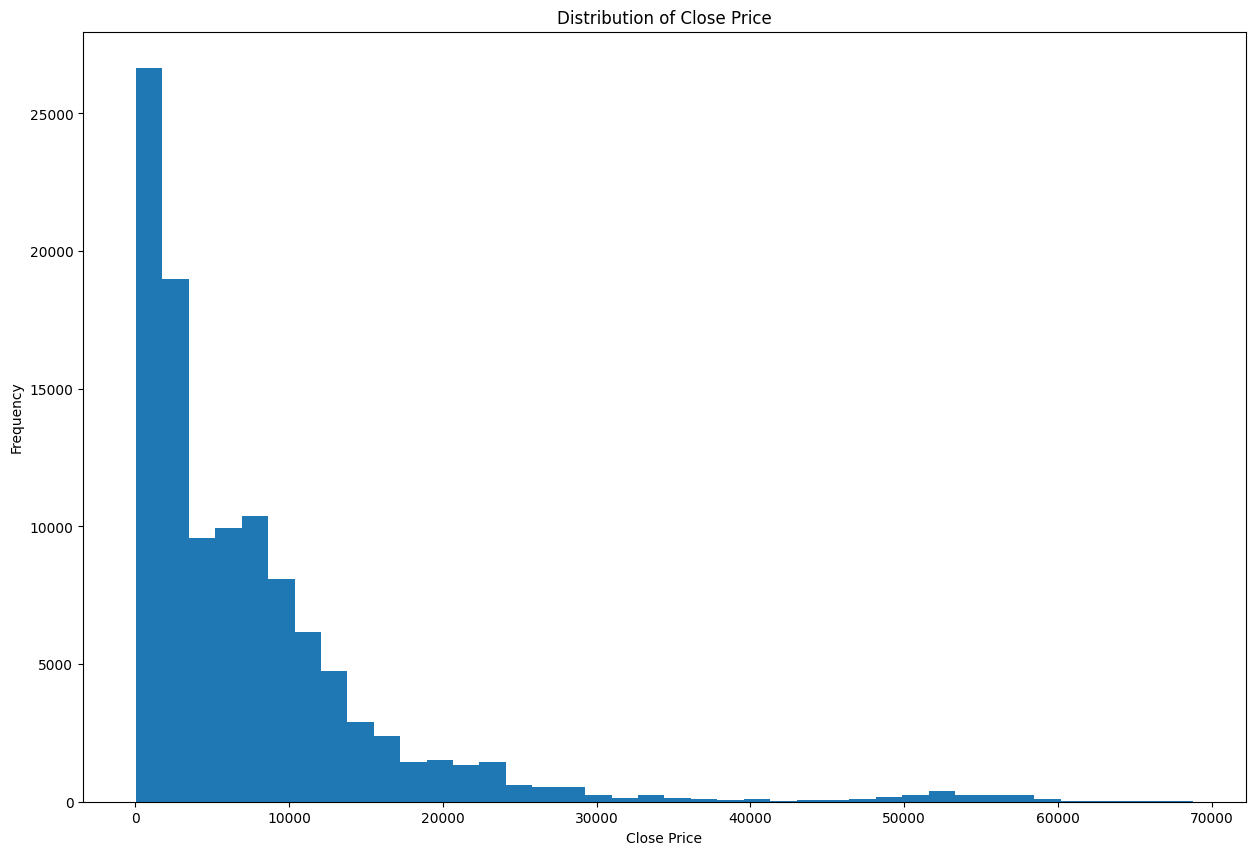

In [18]:
plt.figure(figsize=(15, 10))

plt.hist(df['Close'], bins=40)

plt.title('Distribution of Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.show()

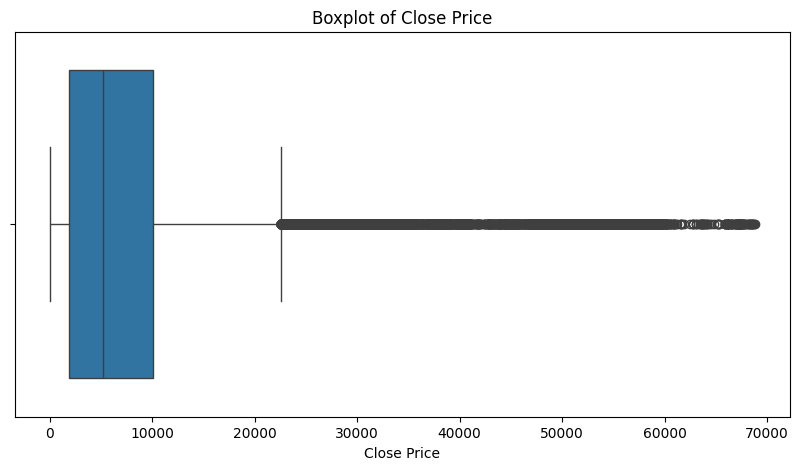

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Close'])

plt.title('Boxplot of Close Price')
plt.xlabel('Close Price')

plt.show()

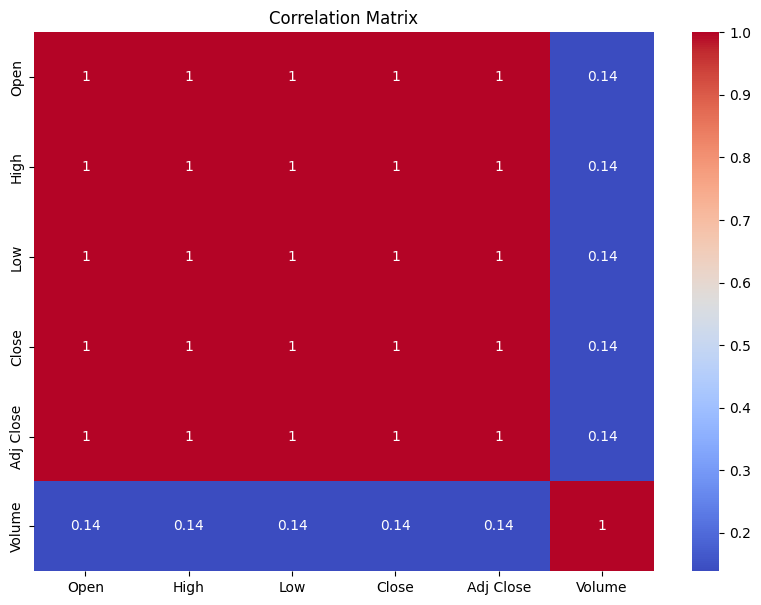

In [20]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

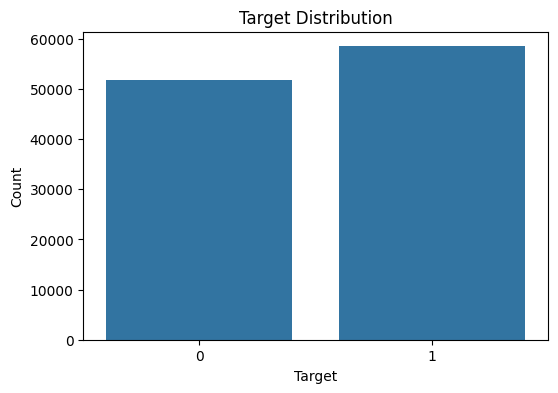

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Target', data=df)

plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

In [22]:
df.to_csv('processed_market_data.csv', index=False)

In [23]:
import os

print(os.path.exists('processed_market_data.csv'))

True


## Conclusion

The dataset was checked for missing values and duplicate records.
No missing values or duplicate records were found.

Feature engineering was performed on the Date column by extracting
Year, Month, Day, and Day of Week.

EDA visualizations such as the histogram, boxplot, correlation
heatmap, and target distribution were used to understand the dataset.